# Explore – NRW Mietdaten

This notebook corresponds to the **Explore** phase of the OSEMN framework.
It focuses on descriptive statistics and visual exploration of rental prices
without applying hypothesis testing or modeling.

Dieses Notebook nutzt ausschließlich den bereinigten Datensatz aus data/processed/nrw_clean.csv und beantwortet Forschungsfragen explorativ.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/nrw_clean.csv")
df.shape


(62824, 11)

In [3]:
df.head()


,regio2,regio3,baseRent,totalRent,livingSpace,noRooms,balcony,hasKitchen,newlyConst,yearConstructed,price_per_sqm
0,Dortmund,Schüren,595.0,840.00,86.00,4.0,False,False,False,1965.0,6.918605
1,Gelsenkirchen,Bulmke_Hüllen,300.0,NaN,60.00,2.5,False,False,False,1953.0,5.000000
2,Hamm,Mitte,950.0,1150.00,123.44,4.0,False,False,False,1951.0,7.696047
3,Dortmund,Kirchhörde,972.6,1320.65,87.00,3.0,True,False,True,2018.0,11.179310
4,Duisburg,Obermarxloh,329.0,NaN,65.00,2.5,True,False,False,1914.0,5.061538


In [4]:
df.isna().sum()


regio2                 0
regio3                 0
baseRent               0
totalRent          12092
livingSpace            0
noRooms                0
balcony                0
hasKitchen             0
newlyConst             0
yearConstructed    12038
price_per_sqm          0
dtype: int64

## Forschungsfrage 1 (Stadtvergleich)

Top-10 Städte nach Anzahl der Inserate

In [5]:
top_cities = df["regio2"].value_counts().head(10).index
top_cities


Index(['Essen', 'Düsseldorf', 'Duisburg', 'Dortmund', 'Gelsenkirchen',
       'Recklinghausen_Kreis', 'Köln', 'Wuppertal', 'Bochum', 'Aachen'],
      dtype='object')

Tabelle: Median €/m² + Anzahl

In [7]:
rq1_table = (
    df[df["regio2"].isin(top_cities)]
    .groupby("regio2")
    .agg(
        median_eur_per_sqm=("price_per_sqm", "median"),
        n_offers=("price_per_sqm", "size")
    )
    .sort_values("median_eur_per_sqm", ascending=False)
)

rq1_table


,median_eur_per_sqm,n_offers
regio2,,
Köln,12.567444,2702
Düsseldorf,11.988548,3709
Aachen,9.420290,1889
Dortmund,7.707160,3135
Essen,7.222368,4350
Bochum,7.142857,2007
Wuppertal,6.500000,2376
Recklinghausen_Kreis,6.168831,2754
Duisburg,6.020558,3519


Plot(Balken)

rq1_table["median_eur_per_sqm"].sort_values().plot(kind="barh")
plt.xlabel("Median €/m²")
plt.ylabel("Stadt (Top 10 nach Anzahl)")
plt.title("RQ1: Median-Mietpreis pro m² in NRW (Top 10 Städte)")
plt.tight_layout()
plt.show()


## Forschungsfrage 2 (Wohnungsgröße)

Gruppe bilden

In [9]:
small = df[df["livingSpace"] < 50]
medium = df[(df["livingSpace"] >= 50) & (df["livingSpace"] <= 80)]
large = df[df["livingSpace"] > 80]


Mediane + Tabelle

In [10]:
rq2_table = pd.DataFrame({
    "group": ["<50", "50-80", ">80"],
    "median_eur_per_sqm": [
        small["price_per_sqm"].median(),
        medium["price_per_sqm"].median(),
        large["price_per_sqm"].median()
    ],
    "n_offers": [len(small), len(medium), len(large)]
})

rq2_table


,group,median_eur_per_sqm,n_offers
0,<50,8.238929,9195
1,50-80,6.686974,33824
2,>80,7.960631,19805


Boxplot

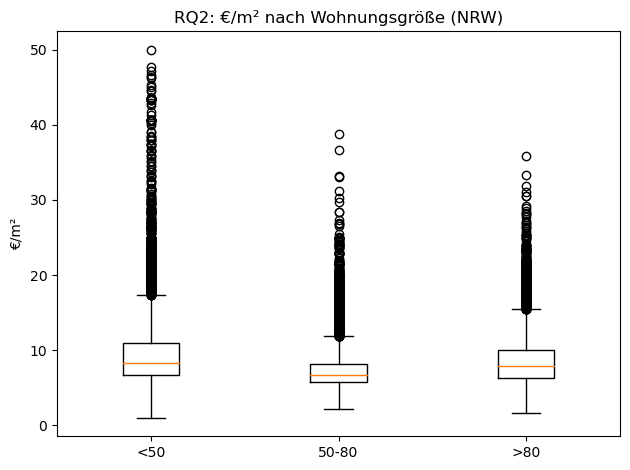

In [11]:
plt.boxplot(
    [small["price_per_sqm"], medium["price_per_sqm"], large["price_per_sqm"]],
    labels=["<50", "50-80", ">80"]
)
plt.ylabel("€/m²")
plt.title("RQ2: €/m² nach Wohnungsgröße (NRW)")
plt.tight_layout()
plt.show()
